# Tesis MIA — Versión A: *Baseline* Transformer–Difusión y diagnóstico de atención


Implementa el **núcleo defendible (Versión A)** —tokenización multivariada, *encoder* Transformer causal y cabeza latente probabilística— y ejecuta el experimento que concentra el **riesgo científico real**: el **diagnóstico de colapso de atención**.

> **Fidelidad a la memoria de cálculo (Mathcad, Partes 2A/2B).** La Fase 1 reproduce *función por función* tu `Phase1Tokenizer`: **`NormalizeX` → `FlattenTokens` → `InputProjection` → `PE_dual` → suma**, con las mismas verificaciones dimensionales (`rows(H0)=45=N·L`, `cols(H0)=32=d_model`).

 · Profesor: **Marcelo Mendoza**

 · Alumno: **Mauricio Riquelme Alvarado**

 · MIA-PUC



## 0. Configuración y semillas

In [2]:
try:
    import torch, numpy as np, matplotlib  # noqa
except Exception:
    import subprocess, sys
    subprocess.run([sys.executable,"-m","pip","install","-q","torch","numpy","matplotlib"])
import math, numpy as np, torch, torch.nn as nn
import matplotlib.pyplot as plt
SEED=42; np.random.seed(SEED); torch.manual_seed(SEED)
DEV="cuda" if torch.cuda.is_available() else "cpu"
print("torch", torch.__version__, "| device:", DEV)

torch 2.11.0+cpu | device: cpu


## 1. Parámetros del modelo
Idénticos a la verificación Mathcad: $d_{ff}=4\,d_{model}$ (convención Vaswani 2017), $d_k=d_{model}$, $N_{layers}=3$, $\varepsilon=10^{-6}$.

In [3]:
N, L   = 3, 15                 # 3 series (Cu, USD/CLP, TPM) x 15 pasos
D      = 32                    # d_model
DFF    = 4 * D                 # d_ff = 4*d_model = 128  (Mathcad / Vaswani)
NL     = 3                     # bloques del encoder (N_layers)
H      = 4                     # cabezas de MHA (en Mathcad la verificación usa d_k=d_model; aquí multi-cabeza)
EPS    = 1e-6                  # eps_norm (guarda numérica)
NAMES  = ["Cu", "USD/CLP", "TPM"]
print(f"{N*L} tokens | d_model={D} | d_ff={DFF} | {NL} capas | {H} cabezas (d_k={D//H})")

45 tokens | d_model=32 | d_ff=128 | 3 capas | 4 cabezas (d_k=8)


## 2. Datos — elegir la fuente
La celda siguiente **pregunta qué datos usar**; las dos opciones son mutuamente excluyentes y ambas traen la causalidad de dominio Cu→USD/CLP→TPM como **verdad de terreno**:

- **`"parte1"`** — carga los niveles generados por el cuaderno **Parte 1** (`GARCH(1,1)` + enlace causal vía $G$ + `ARIMA(1,1,1)`), leídos desde Google Drive (`sistema_economico_levels.npy`, forma `[N, T]`). Son series de **nivel I(1)** (random-walk), con la estructura causal ya inyectada en las innovaciones.
- **`"sintetico"`** — generador de juguete acoplado (AR estacionario) con **escalas realistas por serie** (Cu≈3.5 USD/lb, USD/CLP≈850, TPM≈5%) y la misma cadena Cu→FX→TPM.

En ambos casos las escalas por serie son muy dispares, que es justo la razón por la que **`NormalizeX`** (z-score **por variable**) es indispensable aguas abajo.

> **Nota:** con `"parte1"` los niveles son **I(1)** (no estacionarios); la tarea de pronóstico —y el diagnóstico T0.3— pueden verse distintos que con el sintético estacionario.

> **Hook a datos reales:** reemplaza la fuente por la carga de Cochilco (cobre) y BCCh (USD/CLP, TPM), 2003–2024 mensual, con forma `[N, T]`. El resto no cambia.

In [4]:
import os

# --- Generador del Sistema Económico (Parte 1: GARCH + Causal_Link + ARIMA) ---
_PCu,_PUSD,_PTPM = (0.04,0.05,0.30),(0.03,0.03,0.05),(0.01,0.01,0.90)   # GARCH (ω,α,β)
_PHI,_THETA,_S0  = [0.5,0.2,0.1],[0.05,0.05,0.05],[100,100,100]          # ARIMA (φ,θ,S0)
_G = np.array([[1.,0.,0.],[-0.6,1.,0.],[0.4,-0.2,1.]])
def _GARCH(T,w,a,b,z):
    h=np.zeros(T); e=np.zeros(T); h[0]=w/(1-a-b); e[0]=z[0]*np.sqrt(h[0])
    for t in range(1,T): h[t]=w+a*e[t-1]**2+b*h[t-1]; e[t]=z[t]*np.sqrt(h[t])
    return e
def _ARIMA(eps,phi,th,S0,T):
    S=np.zeros(T); dx=np.zeros(T); S[0]=S0
    for t in range(1,T): dx[t]=phi*dx[t-1]+th*eps[t-1]+eps[t]; S[t]=S[t-1]+dx[t]
    return S
def _Causal(Zb,G):
    c,u,g=Zb[:,0],Zb[:,1],Zb[:,2]
    return np.stack([c,u+G[1,0]*c,g+G[2,0]*c+G[2,1]*u],1)
def gen_parte1(T=4000, seed=0):
    rng=np.random.default_rng(seed)
    Zc=_Causal(np.stack([rng.normal(0,1,T),rng.normal(0,1,T),rng.normal(0,1,T)],1),_G)
    S=[_ARIMA(_GARCH(T,*P,Zc[:,i]),_PHI[i],_THETA[i],_S0[i],T) for i,P in enumerate([_PCu,_PUSD,_PTPM])]
    return np.stack(S,0)                          # [N,T] niveles I(1)

# --- Generador sintético de juguete (AR estacionario) ---
def gen_series(T=4000, seed=0):
    rng = np.random.default_rng(seed)
    cu, fx, tpm = np.zeros(T), np.zeros(T), np.zeros(T)
    for t in range(1, T):
        cu[t]  = 0.85*cu[t-1]                 + rng.normal(0, 1.0)
        fx[t]  = 0.80*fx[t-1] - 0.50*cu[t-1]  + rng.normal(0, 0.5)
        tpm[t] = 0.90*tpm[t-1] + 0.40*fx[t-1] + rng.normal(0, 0.3)
    cu, fx, tpm = 3.5+0.4*cu, 850.0+40.0*fx, 5.0+2.0*tpm
    return np.stack([cu, fx, tpm], 0)

def windows(X, L):
    _, T = X.shape; xs, ys = [], []
    for s in range(T - L - 1):
        xs.append(X[:, s:s+L]); ys.append(X[:, s+L])
    return np.stack(xs).astype("float32"), np.stack(ys).astype("float32")

# --- Elige la fuente ---
FUENTE_DATOS = ""
while FUENTE_DATOS not in ("parte1", "sintetico"):
    FUENTE_DATOS = input("Fuente de datos -> escribe 'parte1' o 'sintetico': ").strip().lower()

if FUENTE_DATOS == "parte1":
    ARCHIVO_PARTE1 = "/content/drive/MyDrive/sistema_economico_levels.npy"
    cargado = False
    try:
        from google.colab import drive
        drive.mount('/content/drive')
        if os.path.exists(ARCHIVO_PARTE1):
            X_raw = np.load(ARCHIVO_PARTE1)
            assert X_raw.shape[0] == N, f"Se esperaban {N} series, se obtuvieron {X_raw.shape[0]}"
            print(f"✓ Datos de la Parte 1 cargados desde Drive: {X_raw.shape}")
            cargado = True
    except Exception as e:
        print(f"⚠ No se pudo acceder a Drive ({type(e).__name__}). Se generará el sistema en memoria.")
    if not cargado:
        print(f"⚠ '{ARCHIVO_PARTE1}' no encontrado -> GENERANDO el sistema económico (Parte 1) en esta sesión.")
        X_raw = gen_parte1()
        print(f"✓ Sistema Económico (Parte 1) generado en memoria: {X_raw.shape}")
else:  # "sintetico"
    X_raw = gen_series()
    print(f"✓ Datos sintéticos (generador de juguete): {X_raw.shape}")

Xw_raw, Yw_raw = windows(X_raw, L)
print("rango por serie (crudo):",
      {NAMES[i]: (round(float(X_raw[i].min()),1), round(float(X_raw[i].max()),1)) for i in range(N)})

Fuente de datos -> escribe 'parte1' o 'sintetico': parte1
Mounted at /content/drive
✓ Datos de la Parte 1 cargados desde Drive: (3, 1000)
rango por serie (crudo): {'Cu': (97.3, 131.9), 'USD/CLP': (91.3, 100.5), 'TPM': (87.0, 115.1)}


## 3. Tokenización multivariada — Fase 1   *(réplica fiel de `Phase1Tokenizer` de Mathcad)*

Las cuatro operaciones encadenadas de la memoria de cálculo, con la verificación dimensional en cada paso:

| Función Mathcad | Operación | Salida |
|---|---|---|
| `NormalizeX(X)` | z-score **por variable** (fila), guarda $\varepsilon$ | $[N\times L]$, $O(1)$ |
| `FlattenTokens(X)` | aplanado *row-major* $\mathrm{idx}=nL+t$ | $[45\times1]$ |
| `InputProjection(T)` | afín escalar $\to\mathbb{R}^{32}$ | $[45\times32]$ |
| `PE_dual(N,L,d)` | $PE_t(t)+PE_v(n)$ | $[45\times32]$ |
| `Phase1Tokenizer` | suma $\to H_0$ | $[45\times32]$ ✓ |

In [ ]:
def NormalizeX(X):
    """z-score POR VARIABLE (fila) con guarda eps. Raíz real del colapso O(1e9):
    los datos crudos están a ~100s y con escalas dispares; sin esto IP queda en O(1e2)."""
    mu = X.mean(-1, keepdim=True)
    sd = X.std(-1, keepdim=True)
    return (X - mu) / (sd + EPS)                       # O(100s) -> O(1)

def FlattenTokens(X):
    """Aplanado row-major por variable: idx = n*L + t -> T [B,45,1].
    tokens 0-14=Cu, 15-29=USD/CLP, 30-44=TPM."""
    B = X.shape[0]
    return X.reshape(B, N*L, 1)

def PE_temporal(L, D):
    """PE_t: codificación temporal sinusoidal (Vaswani 2017) -> [L,D]."""
    pe = torch.zeros(L, D); pos = torch.arange(L).unsqueeze(1).float()
    div = 10000.0 ** (torch.arange(0, D, 2).float() / D)
    pe[:, 0::2] = torch.sin(pos/div); pe[:, 1::2] = torch.cos(pos/div)
    return pe

class Phase1Tokenizer(nn.Module):
    """Orquesta la Fase 1 igual que en Mathcad:
       (NormalizeX) -> FlattenTokens -> InputProjection -> + PE_dual -> H0."""
    def __init__(self):
        super().__init__()
        self.InputProjection = nn.Linear(1, D)              # IP: escalar -> R^32 (afín)
        self.PE_variable     = nn.Embedding(N, D)           # PE_v: embedding de identidad de serie
        idx_n = torch.arange(N).repeat_interleave(L)        # n de cada token (idx=n*L+t)
        idx_t = torch.arange(L).repeat(N)                   # t de cada token
        self.register_buffer("PE_t", PE_temporal(L, D)[idx_t])   # PE_t alineado a 45 tokens
        self.register_buffer("idx_n", idx_n)
    def PE_dual(self):
        # PE_dual[idx,:] = PE_temporal[t,:] + PE_variable[n,:]
        return self.PE_t + self.PE_variable(self.idx_n)     # [45,D]
    def forward(self, X, normalize=True, verify=False):
        if normalize:
            X = NormalizeX(X)                               # raíz del 1e9
        T  = FlattenTokens(X)                               # [B,45,1]
        H  = self.InputProjection(T)                        # [B,45,32]
        H0 = H + self.PE_dual().unsqueeze(0)                # [B,45,32]
        if verify:  # verificación dimensional (memoria de cálculo)
            assert H0.shape[1] == N*L == 45, "rows(H0) != N*L"
            assert H0.shape[2] == D == 32,   "cols(H0) != d_model"
        return H0
print("Fase 1 (Phase1Tokenizer) definida.")

Fase 1 (Phase1Tokenizer) definida.


### 3.1 Verificación tipo *memoria de cálculo* ✓
Replicamos el bloque de validación de Mathcad sobre una **ventana cruda** (escalas ~100s): comprobamos que `NormalizeX` lleva la entrada de $O(10^2)$ a $O(1)$ y que $H_0$ tiene dimensiones $45\times32$.

In [ ]:
tok = Phase1Tokenizer().to(DEV)
x_win = torch.tensor(Xw_raw[:1], device=DEV)               # 1 ventana CRUDA [1,3,15]
print("máx|X| crudo      :", round(float(x_win.abs().max()), 1), " (O(100s), escalas dispares)")
print("máx|NormalizeX(X)| :", round(float(NormalizeX(x_win).abs().max()), 3), " -> O(1) ✓")

H0 = tok(x_win, normalize=True, verify=True)
print(f"H0 dims: rows={H0.shape[1]}=N·L ✓   cols={H0.shape[2]}=d_model ✓")
print("máx|H0| :", round(float(H0.abs().max()), 2), " (acotado, O(1) gracias a NormalizeX)")
# contraste: sin NormalizeX, IP queda en O(100s) -> raíz del 1e9
print("máx|H0 SIN NormalizeX| :", round(float(tok(x_win, normalize=False).abs().max()), 1), " (O(100s) -> colapso aguas abajo)")

máx|X| crudo      : 101.8  (O(100s), escalas dispares)
máx|NormalizeX(X)| : 2.475  -> O(1) ✓
H0 dims: rows=45=N·L ✓   cols=32=d_model ✓
máx|H0| : 4.85  (acotado, O(1) gracias a NormalizeX)
máx|H0 SIN NormalizeX| : 99.6  (O(100s) -> colapso aguas abajo)


## 4. *Encoder* Transformer causal — Fase 2
**Máscara de causalidad temporal sobre $t_i=i\bmod L$** (no sobre el índice global): ningún token atiende a un mes futuro, pero las dependencias cruzadas pasadas/contemporáneas quedan libres. La MHA **devuelve los mapas de atención**. Cada bloque aplica `LayerNorm(x + sublayer)` (Add & Norm corregido en Fase 0).

In [ ]:
def causal_mask_modL(N, L):
    idx = torch.arange(N*L); ti = idx % L
    return torch.where(ti[None, :] <= ti[:, None], 0.0, float("-inf"))   # [45,45]

class MHA(nn.Module):
    def __init__(self):
        super().__init__()
        self.q=nn.Linear(D,D); self.k=nn.Linear(D,D); self.v=nn.Linear(D,D); self.o=nn.Linear(D,D)
        self.dk = D // H
    def forward(self, x, mask):
        B, S, _ = x.shape
        sp = lambda t: t.view(B, S, H, self.dk).transpose(1, 2)
        q, k, v = sp(self.q(x)), sp(self.k(x)), sp(self.v(x))
        sc = q @ k.transpose(-2, -1) / math.sqrt(self.dk) + mask
        att = sc.softmax(-1)                                            # [B,H,S,S]
        out = (att @ v).transpose(1, 2).reshape(B, S, D)
        return self.o(out), att

class Block(nn.Module):
    def __init__(self):
        super().__init__()
        self.mha=MHA(); self.ln1=nn.LayerNorm(D); self.ln2=nn.LayerNorm(D)
        self.ff=nn.Sequential(nn.Linear(D,DFF), nn.ReLU(), nn.Linear(DFF,D))
    def forward(self, x, m):
        a, att = self.mha(x, m)
        x = self.ln1(x + a)            # ResidualAdd (Add & Norm)
        x = self.ln2(x + self.ff(x))   # ResidualAdd (Add & Norm)
        return x, att
print("Encoder (máscara mod-L + MHA con extracción de atención) definido.")

Encoder (máscara mod-L + MHA con extracción de atención) definido.


## 5. Cabeza latente probabilística — Fase 3
`TemporalPooling` agrega los 45 tokens en $z_{enc}\in\mathbb{R}^{32}$; de ahí $\mu,\sigma$ (reparametrización) y un decodificador gaussiano. Pérdida de la Versión A: $\mathcal{L}_{simple}=\mathcal{L}_{recon}+\beta\,\mathrm{KL}$. El módulo de difusión latente (DDPM/DDIM) reemplaza esta cabeza como siguiente paso.

In [ ]:
class ModelA(nn.Module):
    def __init__(self):
        super().__init__()
        self.tok = Phase1Tokenizer()                       # Fase 1 fiel a Mathcad
        self.blocks = nn.ModuleList([Block() for _ in range(NL)])
        self.register_buffer("mask", causal_mask_modL(N, L))
        self.mu = nn.Linear(D, D); self.lv = nn.Linear(D, D)
        self.dec = nn.Sequential(nn.Linear(D, DFF), nn.ReLU(), nn.Linear(DFF, 2*N))
    def forward(self, X, ret_attn=False):
        h = self.tok(X, normalize=False)                   # datos ya normalizados (ver celda de datos)
        atts = []
        for b in self.blocks:
            h, a = b(h, self.mask); atts.append(a)
        z_enc = h.mean(1)                                  # TemporalPooling -> [B,D]
        mu, lv = self.mu(z_enc), self.lv(z_enc)
        z = mu + torch.exp(0.5*lv) * torch.randn_like(lv)  # reparametrización
        o = self.dec(z); ym, ylv = o[:, :N], o[:, N:]
        return ym, ylv, mu, lv, (torch.stack(atts) if ret_attn else None)

def loss_fn(ym, ylv, Y, mu, lv, beta=0.1):
    nll = 0.5 * (((Y - ym)**2) * torch.exp(-ylv) + ylv).sum(1).mean()
    kl  = -0.5 * (1 + lv - mu**2 - lv.exp()).sum(1).mean()
    return nll + beta*kl, nll.item(), kl.item()

# Datos para entrenar: NormalizeX por serie sobre TODA la serie (stats globales, sin fuga) -> ventanas
Xn = NormalizeX(torch.tensor(X_raw, dtype=torch.float32)).numpy()
Xw, Yw = windows(Xn, L)
ntr = int(0.8*len(Xw))
Xtr = torch.tensor(Xw[:ntr], device=DEV); Ytr = torch.tensor(Yw[:ntr], device=DEV)
Xte = torch.tensor(Xw[ntr:], device=DEV); Yte = torch.tensor(Yw[ntr:], device=DEV)
print("ModelA listo | train:", Xtr.shape[0], "| test:", Xte.shape[0])

ModelA listo | train: 787 | test: 197


## 6. Entrenamiento Versión A + chequeo de Fase 0
Verificamos la condición de salida de Fase 0: convergencia **sin explosión** ($O(10^9)$ era el síntoma sin residuales/LayerNorm).

In [ ]:
torch.manual_seed(SEED)
model = ModelA().to(DEV)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
B, STEPS, max_mag = 256, 400, 0.0
for step in range(STEPS):
    idx = torch.randint(0, len(Xtr), (B,), device=DEV)
    X, Y = Xtr[idx], Ytr[idx]
    ym, ylv, mu, lv, _ = model(X)
    loss, nll, kl = loss_fn(ym, ylv, Y, mu, lv, beta=0.1)
    opt.zero_grad(); loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    opt.step()
    max_mag = max(max_mag, float(ym.detach().abs().max()))
    if step % 100 == 0:
        print(f"step {step:3d} | loss {loss.item():7.4f} | nll {nll:7.4f} | kl {kl:6.3f}")
print(f"\n[Fase 0] magnitud máx de salida = {max_mag:.2f}  ->  "
      f"{'OK (sin explosión O(1e9))' if max_mag < 1e3 else 'EXPLOSIÓN'}")

step   0 | loss  1.9376 | nll  1.6123 | kl  3.253
step 100 | loss -0.7642 | nll -1.5717 | kl  8.075
step 200 | loss -1.4491 | nll -2.4693 | kl 10.201
step 300 | loss -1.9967 | nll -3.1417 | kl 11.450

[Fase 0] magnitud máx de salida = 2.92  ->  OK (sin explosión O(1e9))


## 7. Diagnóstico de atención (T0.3) — *el riesgo real*
Extraemos la atención **real** del *encoder* entrenado, la agregamos a $\bar W_{att}\in\mathbb{R}^{3\times3}$ y medimos colapso vía entropía normalizada (1 = uniforme = sin estructura).

In [ ]:
model.eval()
with torch.no_grad():
    _, _, _, _, att = model(Xtr[:512], ret_attn=True)   # [NL,B,H,45,45]
A = att.mean((0, 1, 2))                                  # promedio capas/batch/cabezas -> [45,45]
valid = (causal_mask_modL(N, L) == 0).float().to(A.device)
ent = -(A * torch.clamp(A, 1e-9).log()).sum(1)
ent_norm = (ent / torch.log(valid.sum(1))).mean().item()
Wbar = A.view(N, L, N, L).mean((1, 3))
Wbar = (Wbar / Wbar.sum(1, keepdim=True)).cpu().numpy()
print(f"Entropía de atención normalizada: {ent_norm:.3f}  (cercana a 1 => colapso a uniforme)")
print("W_bar (atención real agregada, fila = serie consultante):"); print(np.round(Wbar, 3))

Entropía de atención normalizada: 0.995  (cercana a 1 => colapso a uniforme)
W_bar (atención real agregada, fila = serie consultante):
[[0.287 0.291 0.422]
 [0.307 0.297 0.396]
 [0.332 0.35  0.318]]


## 8. Prior estructural $\Pi(G)$ y regularización $R_G$
Proyección del grafo causal (cada serie atiende a sí misma y a sus *padres*), y $R_G=\mathcal{D}(\bar W_{att},\Pi(G))$ en MSE y KL **sobre la atención real**.

R_G sobre atención REAL  ->  MSE = 0.1303   |   KL = 0.7192


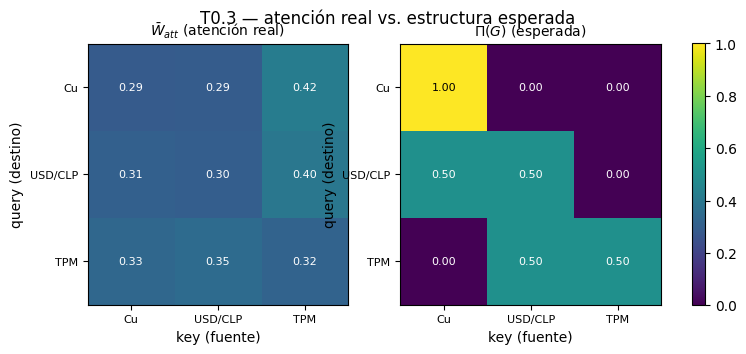

In [ ]:
PiG = np.array([[1,0,0],[1,1,0],[0,1,1]], dtype="float32"); PiG = PiG / PiG.sum(1, keepdims=True)
RG_mse = float(((Wbar - PiG)**2).mean())
RG_kl  = float((PiG * (np.log(PiG+1e-9) - np.log(Wbar+1e-9))).sum(1).mean())
print(f"R_G sobre atención REAL  ->  MSE = {RG_mse:.4f}   |   KL = {RG_kl:.4f}")
fig, ax = plt.subplots(1, 2, figsize=(8, 3.4))
for a, M, t in zip(ax, [Wbar, PiG], ["$\\bar W_{att}$ (atención real)", "$\\Pi(G)$ (esperada)"]):
    im = a.imshow(M, vmin=0, vmax=1, cmap="viridis")
    a.set_xticks(range(N)); a.set_yticks(range(N))
    a.set_xticklabels(NAMES, fontsize=8); a.set_yticklabels(NAMES, fontsize=8)
    a.set_title(t, fontsize=10); a.set_xlabel("key (fuente)"); a.set_ylabel("query (destino)")
    for i in range(N):
        for j in range(N):
            a.text(j, i, f"{M[i,j]:.2f}", ha="center", va="center",
                   color="white" if M[i,j] < 0.6 else "black", fontsize=8)
fig.colorbar(im, ax=ax, fraction=0.025); plt.suptitle("T0.3 — atención real vs. estructura esperada"); plt.show()

## 9. Lectura del diagnóstico y próximos pasos

**Hallazgo.** Con causalidad conocida, la atención agregada real es **casi uniforme** (entropía $\approx 1$) y **no recupera** $\Pi(G)$: $R_G$ real queda lejos de cero por *falta de estructura*, no por penalización. Validar $R_G$ solo sobre atención sintética **no prueba** que funcione sobre la real.

**Candidatos a probar (Fase 0/1):** (1) temperatura de atención; (2) regularización de entropía; (3) inspección por cabeza/capa (no solo el promedio); (4) más señal de tarea ($h>1$ o cabeza de difusión latente).

**Siguiente cuaderno (oferta):** líneas base ARIMA/GARCH, LSTM, TFT + métricas **CRPS, Energy Score y Diebold–Mariano** (H2) y el cargador de datos reales Cochilco/BCCh.